# Chapter 2 — Modern Liability
### *Modern Strain Gage Technology* — Companion Notebook

*Documented measurement is not bureaucratic overhead — it is evidence that outlives everyone who made the decision.*

Companion notebook to Chapter 2 — Modern Liability.

Engineering decisions made today can be litigated a decade from now. A structure tested in 2025 may be the subject of discovery requests in 2035 — after the engineers who ran the test have changed jobs, the company that built it has been acquired, and the test facility has been reconfigured. What survives that decade? Documented measurement records. What does not? Everything else.

The legal and economic context for measurement is often neglected in engineering education. The focus is on technical accuracy — getting the right number. But the second question — can you prove you got the right number — is equally important in the real world. Calibration certificates, data acquisition configurations, environmental conditions, and raw data archives are not bureaucratic overhead. They are evidence. They allow an engineer to stand behind measurements made years ago in a forum where "I remember it was around 1000 microstrain" is not acceptable.

Both halves of that argument have been measured by somebody. Economists have estimated how fast an organization forgets what it once knew how to do; the Bureau of Labor Statistics reports how long people stay with an employer; and forty-eight US jurisdictions have written into statute exactly how long an engineer remains exposed to a claim. This notebook puts those published numbers on one pair of axes instead of asserting the shape of the curve.

**This notebook demonstrates:**
1. Knowledge retention after a test, using published estimates of organizational forgetting and personnel tenure, against the statutory window in which the work can still be litigated
2. The distribution of US construction statutes of repose — the empirical basis for that window

In [ ]:
# Colab setup: install the packages this notebook uses.
# !pip install numpy matplotlib

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# This notebook is fully deterministic: the curves are analytic decay functions
# fitted to published point estimates, with no random sampling, so no RNG seed
# is required for reproducibility.

OUT_DIR = Path('../src/media/ch02')
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — How Fast Knowledge Decays, and How Long You Stay Liable

The claim that undocumented knowledge decays is not folklore; it has been estimated repeatedly, and the estimates disagree sharply. Argote, Beckman, and Epple (1990), studying the WWII Liberty ship yards, found depreciation so rapid that only about **3.2% of an organization's knowledge stock survived a year** — a half-life under three months. Benkard (2000), working from Lockheed L-1011 production records, put annual survival at **61%**. Thompson (2007), returning to the Liberty ship data with better primary sources from the National Archives, found rates of forgetting *much* smaller than previously reported and possibly **zero**.

That spread is the honest state of the evidence, and the figure below plots it as a band rather than pretending to a single curve. Two cautions come with it. First, all three studies measure *organizational production knowledge* — unit labor cost in a shipyard or an aircraft plant — not whether the engineer who ran a strain survey still remembers the bridge completion setting. Second, they measure knowledge that decays because production stops, not because people leave.

For the question this chapter actually cares about — in ten years, can you still find and depose the person who took the reading? — the more direct evidence is tenure. The Bureau of Labor Statistics reported a median tenure with current employer of **3.9 years** in January 2024, the lowest since 2002. Treat that as the median of an exponential and roughly one in six of the original test team is still at that employer a decade later.

Ten years is the number that matters, because it is the one the legislatures picked. Forty-six states impose a statute of repose on claims arising from improvements to real property, and in the state-by-state survey plotted in the right-hand panel, **10 years is both the median and the mode**. The exposure window is not a guess. It is written down.

Against all of that, a documented record is flat. It is worth being precise about why. The intuitive threat — file-format obsolescence — turns out to be the wrong thing to fear: Rosenthal (2010) surveyed the digital-preservation evidence and concluded that format obsolescence "is rare, happening infrequently to rare formats," and that fifteen years of preservation practice had been built on over-estimating it. Widely used, openly specified formats stay readable. What actually destroys an archive is discrete and organizational — a media failure, a decommissioned server, an acquisition, a retention policy that expired — not a smooth exponential. So the documented curve here is drawn flat, and the risk to it is stated in the caveats rather than faked as a decay rate.

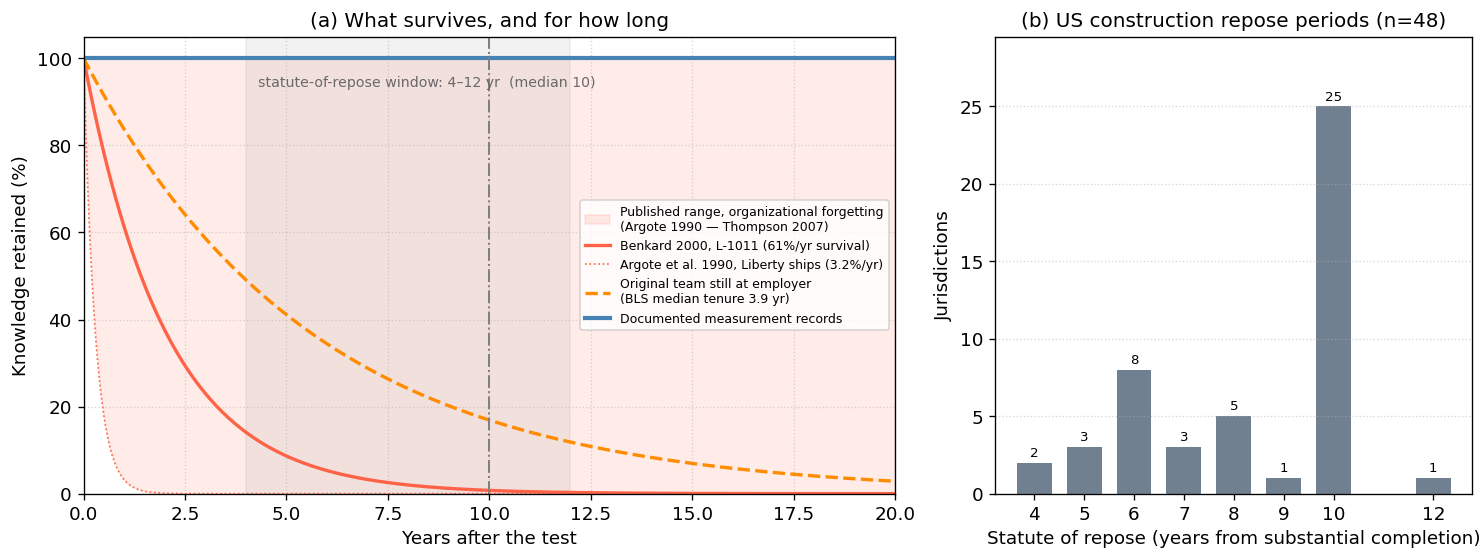

At the median repose horizon of 10 years after the test:
  Benkard 2000 organizational knowledge:   0.75%
  Original team still at that employer:   16.91%
  Documented records:                     100.00%

Repose periods: min 4 yr, median 10 yr, max 12 yr; 26 of 48 jurisdictions are 10 years or longer.


In [ ]:
# Figure 2.2 — knowledge retention against the statutory exposure window.
# Every rate below is a published point estimate; sources are tabulated in the
# markdown cell that follows.

YEARS_SPAN = 20
N_POINTS = 400

# --- Published annual survival fractions for organizational knowledge ---------
ARGOTE_ANNUAL_SURVIVAL = 0.032   # Argote, Beckman & Epple (1990), Liberty ships
BENKARD_ANNUAL_SURVIVAL = 0.613  # Benkard (2000), Lockheed L-1011 (0.96/month)
THOMPSON_ANNUAL_SURVIVAL = 1.00  # Thompson (2007): "may well be zero" forgetting

# --- Personnel availability, from median employer tenure ----------------------
BLS_MEDIAN_TENURE_YEARS = 3.9    # BLS, Employee Tenure in 2024 (January 2024)

# --- Statutes of repose, improvements to real property, by jurisdiction -------
# Years from substantial completion for claims against design professionals.
# Where a statute sets a base period with a conditional extension, the outer
# bound is used. Source: White and Williams LLP, Nationwide Limitation and
# Repose Periods. KS, KY and VT are not listed with a design-professional
# repose period (Kentucky's was held unconstitutional).
REPOSE_YEARS = {
    'AL': 7, 'AK': 10, 'AZ': 8, 'AR': 5, 'CA': 10, 'CO': 6, 'CT': 7, 'DE': 6,
    'DC': 10, 'FL': 10, 'GA': 8, 'HI': 10, 'ID': 6, 'IL': 10, 'IN': 10, 'IA': 8,
    'LA': 5, 'ME': 10, 'MD': 10, 'MA': 6, 'MI': 6, 'MN': 10, 'MS': 6, 'MO': 10,
    'MT': 10, 'NE': 10, 'NV': 4, 'NH': 8, 'NJ': 10, 'NM': 10, 'NY': 10, 'NC': 6,
    'ND': 10, 'OH': 10, 'OK': 10, 'OR': 10, 'PA': 12, 'RI': 10, 'SC': 8,
    'SD': 10, 'TN': 4, 'TX': 10, 'UT': 9, 'VA': 5, 'WA': 6, 'WV': 10, 'WI': 7,
    'WY': 10,
}


def rate_from_annual_survival(survival):
    """Convert an annual survival fraction to an exponential decay rate (1/yr)."""
    return -np.log(survival) if survival > 0 else np.inf


def rate_from_median(median_years):
    """Exponential decay rate (1/yr) implied by a median survival time."""
    return np.log(2.0) / median_years


t = np.linspace(0, YEARS_SPAN, N_POINTS)
argote = np.exp(-rate_from_annual_survival(ARGOTE_ANNUAL_SURVIVAL) * t)
benkard = np.exp(-rate_from_annual_survival(BENKARD_ANNUAL_SURVIVAL) * t)
thompson = np.full_like(t, THOMPSON_ANNUAL_SURVIVAL)
personnel = np.exp(-rate_from_median(BLS_MEDIAN_TENURE_YEARS) * t)
documented = np.full_like(t, 1.0)

repose = np.array(sorted(REPOSE_YEARS.values()))
repose_median = float(np.median(repose))

fig, (ax, ax2) = plt.subplots(
    1, 2, figsize=(12.5, 4.8), gridspec_kw={'width_ratios': [1.7, 1]})

# --- Panel (a): retention curves ---------------------------------------------
ax.fill_between(t, argote * 100, thompson * 100, color='tomato', alpha=0.12,
                label='Published range, organizational forgetting\n(Argote 1990 — Thompson 2007)')
ax.plot(t, benkard * 100, color='tomato', linewidth=2,
        label='Benkard 2000, L-1011 (61%/yr survival)')
ax.plot(t, argote * 100, color='tomato', linewidth=1, linestyle=':',
        label='Argote et al. 1990, Liberty ships (3.2%/yr)')
ax.plot(t, personnel * 100, color='darkorange', linewidth=2, linestyle='--',
        label=f'Original team still at employer\n(BLS median tenure {BLS_MEDIAN_TENURE_YEARS} yr)')
ax.plot(t, documented * 100, color='steelblue', linewidth=2.5,
        label='Documented measurement records')

ax.axvspan(repose.min(), repose.max(), color='gray', alpha=0.10)
ax.axvline(repose_median, color='gray', linestyle='-.', linewidth=1.2)
ax.text(repose.min() + 0.3, 96,
        f'statute-of-repose window: {repose.min()}\u2013{repose.max()} yr'
        f'  (median {repose_median:.0f})',
        fontsize=8.5, color='dimgray', va='top')

ax.set_xlabel('Years after the test')
ax.set_ylabel('Knowledge retained (%)')
ax.set_title('(a) What survives, and for how long')
ax.set_xlim(0, YEARS_SPAN)
ax.set_ylim(0, 105)
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(fontsize=7.5, loc='center right')

# --- Panel (b): the statutory window is not a guess ---------------------------
values, counts = np.unique(repose, return_counts=True)
ax2.bar(values, counts, width=0.7, color='slategray')
ax2.set_xlabel('Statute of repose (years from substantial completion)')
ax2.set_ylabel('Jurisdictions')
ax2.set_title(f'(b) US construction repose periods (n={repose.size})')
ax2.set_xticks(values)
ax2.grid(True, axis='y', linestyle=':', alpha=0.5)
for v, c in zip(values, counts):
    ax2.text(v, c + 0.4, str(c), ha='center', fontsize=8)
ax2.set_ylim(0, counts.max() * 1.18)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig02_nb1_documentation_value_time.png',
            bbox_inches='tight', dpi=150)
plt.show()

horizon = repose_median
print(f"At the median repose horizon of {horizon:.0f} years after the test:")
print(f"  Benkard 2000 organizational knowledge:  "
      f"{100 * np.exp(-rate_from_annual_survival(BENKARD_ANNUAL_SURVIVAL) * horizon):5.2f}%")
print(f"  Original team still at that employer:   "
      f"{100 * np.exp(-rate_from_median(BLS_MEDIAN_TENURE_YEARS) * horizon):5.2f}%")
print(f"  Documented records:                     100.00%")
print()
print(f"Repose periods: min {repose.min()} yr, median {repose_median:.0f} yr, "
      f"max {repose.max()} yr; {np.sum(repose >= 10)} of {repose.size} "
      f"jurisdictions are 10 years or longer.")

### Figure 2.2 — sources and caveats

| Quantity | Value used | Source |
|---|---|---|
| Organizational knowledge, annual survival (fast bound) | 3.2%/yr; half-life under 3 months | Argote, L., Beckman, S. L., and Epple, D. (1990). "The Persistence and Transfer of Learning in Industrial Settings." *Management Science* 36(2), 140–154. |
| Organizational knowledge, annual survival (central) | 61%/yr (0.96 per month) | Benkard, C. L. (2000). "Learning and Forgetting: The Dynamics of Aircraft Production." *American Economic Review* 90(4), 1034–1054. Lockheed L-1011, 250 aircraft, 1970–1984. |
| Organizational knowledge, annual survival (slow bound) | ≈100%/yr — forgetting "may well be zero" | Thompson, P. (2007). "How Much Did the Liberty Shipbuilders Forget?" *Management Science* 53(6), 908–918. Re-estimated from National Archives primary sources. |
| Median tenure with current employer | 3.9 years (January 2024) | U.S. Bureau of Labor Statistics, *Employee Tenure in 2024*, news release, 26 September 2024. Lowest since January 2002; median for ages 25–34 was 2.7 years, for ages 55–64, 9.6 years. |
| Statutes of repose, improvements to real property | 4–12 years; median and mode 10 | White and Williams LLP, *Nationwide Limitation and Repose Periods*. 46 states impose such a statute. |
| Format obsolescence risk to archived records | Rare for widely used formats; threat historically over-estimated | Rosenthal, D. S. H. (2010). "Format obsolescence: assessing the threat and the defenses." *Library Hi Tech* 28(2), 195–210. |

**Caveats, stated plainly.**

1. **Construct mismatch, and it is the big one.** Argote, Benkard, and Thompson all measure *organizational production knowledge* — how unit labor cost behaves when a plant stops building something and starts again. That is not the same construct as "the test engineer's recollection of a strain survey." Their curves belong on this chart as evidence that undocumented capability decays measurably, and as a bound on how fast; they are not a measurement of engineering memory. The BLS tenure curve is the more direct proxy for the specific question of whether the person can still be found.
2. **The literature does not agree, and the band shows it.** Argote's estimate and Thompson's re-estimate of *the same shipyards* differ by essentially the whole range of the axis. Thompson's, using better primary data, is the more recent and the more conservative. If Thompson is right, organizational forgetting contributes nothing and the argument rests entirely on turnover — which is why the tenure curve is drawn separately rather than folded in.
3. **The repose tabulation involves judgment.** Where a statute sets a base period with a conditional extension (an injury arising in the final year, say), the outer bound is used. Kansas, Kentucky, and Vermont are not included: Kentucky's statute was held unconstitutional in *Perkins v. Northeastern Log Homes* (1991), and the source chart does not list a design-professional repose period for the other two. Repose periods also run from substantial completion, not from the date of the test, so a test performed early in a project is exposed for longer than the panel suggests.
4. **The documented-records line is flat by argument, not by measurement.** Rosenthal's finding is that format obsolescence is the wrong threat, not that archives are immortal. Real archive loss is discrete — a failed medium, a decommissioned system, an acquisition, an expired retention policy — and a smooth decay curve would misrepresent it. Drawing it flat states the ceiling: this is what documentation *can* deliver if it is actually managed.
5. **Exponential is a modeling choice.** Turnover is treated as exponential with the BLS median as its half-life. Real tenure distributions are not exponential — hazard falls with tenure, and older engineers stay much longer (median 9.6 years for ages 55–64) — so the 3.9-year curve is pessimistic for a senior test team and optimistic for a junior one.

---
## Where to take this next

The figure above replaces guessed decay rates with published ones, which mostly reveals how wide the published range is. Concrete ways to narrow it for your own situation:

1. **Measure your own retention curve instead of borrowing the BLS median.** Take the staff roster of a project team from ten years ago and count how many are still reachable at the same organization each year since. That is a directly observed survival curve for the exact question that matters in discovery, and it takes an afternoon with an HR export.

2. **Replace the repose panel with your jurisdiction and your product.** The 4–12 year distribution is for improvements to real property. Product liability repose periods differ, and the federal General Aviation Revitalization Act sets 18 years for aircraft. Re-plot the panel for the statutes that actually govern your work; the exposure horizon is the only number in this figure you cannot afford to approximate.

3. **Model archive loss as a discrete hazard, not a curve.** Following caveat 4, assign each real threat — media failure, system decommissioning, corporate acquisition, retention-policy expiry — an annual probability, and simulate the fraction of archives still readable at year 10. That turns "store it in an open format on managed media" from advice into a comparison between two survival probabilities.

4. **Put a cost on the gap.** Overlay the probability of a legal event in each year against the cost of being unable to defend the measurement, and integrate. That converts the documentation advantage into an expected-value case for an archiving budget — the same move Chapter 1 makes with the I-35W ledger.